In [1]:
# 本机运行配置：HF 走 hf-mirror、绕开慢代理、用空闲 GPU 1（必须在 import 之前设置，否则不生效）
import os
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"   # 避开被 NoMachine 占用的 GPU 0
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
for key in ("http_proxy", "https_proxy", "HTTP_PROXY", "HTTPS_PROXY", "all_proxy", "ALL_PROXY"):
    os.environ.pop(key, None)


# Alpamayo 1.5: VQA capability

This notebook loads example data from the NVIDIA [PhysicalAI-AV Dataset](https://huggingface.co/datasets/nvidia/PhysicalAI-Autonomous-Vehicles) and runs the Alpamayo 1.5 model, producing driving-related answers to user's questions.

In [2]:
import mediapy as mp
import pandas as pd
import physical_ai_av

import torch
from alpamayo1_5.models.alpamayo1_5 import Alpamayo1_5
from alpamayo1_5.load_physical_aiavdataset import load_physical_aiavdataset
from alpamayo1_5 import helper

### Load model and construct data preprocessor

In [3]:
model = Alpamayo1_5.from_pretrained("nvidia/Alpamayo-1.5-10B", dtype=torch.bfloat16, attn_implementation="sdpa").to("cuda")
processor = helper.get_processor(model.tokenizer)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

### Load and prepare data

In [4]:
clip_ids = pd.read_parquet("clip_ids.parquet")["clip_id"].tolist()
clip_id = clip_ids[774]

avdi = physical_ai_av.PhysicalAIAVDatasetInterface()
data = load_physical_aiavdataset(
    clip_id,
    camera_features=[
        avdi.features.CAMERA.CAMERA_FRONT_WIDE_120FOV,
    ],
)

### Chat template preparation

Ask any driving-relevant questions and generate the input for model

In [5]:
question = "Describe the scene."
messages = helper.create_vqa_message(
    data["image_frames"].flatten(0, 1),
    question=question,
    camera_indices=data["camera_indices"],
)

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=False,
    continue_final_message=True,
    return_dict=True,
    return_tensors="pt",
)
print("seq length:", inputs.input_ids.shape)
model_inputs = {"tokenized_data": inputs}
model_inputs = helper.to_device(model_inputs, "cuda")

seq length: torch.Size([1, 779])


### Visualize the video

,,,

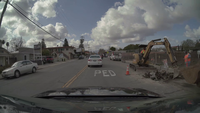
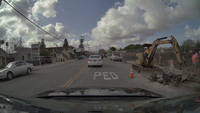
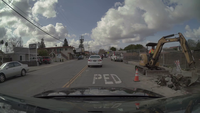
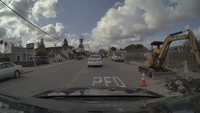

In [6]:
mp.show_images(data["image_frames"].flatten(0, 1).permute(0, 2, 3, 1), columns=4, width=200)

### Model inference

In [7]:
torch.cuda.manual_seed_all(42)
with torch.autocast("cuda", dtype=torch.bfloat16):
    extra = model.generate_text(
        data=model_inputs,
        top_p=0.98,
        temperature=0.6,
        num_samples=1,
        max_generation_length=256,
    )

print("Question:\n", question)
print("Answer:\n", extra["answer"][0])

Question:
 Describe the scene.
Answer:
 ['quito @_;']


### Try a different question

You can ask any driving-relevant question. Here we ask a question that requires the model to reason about the scene.

In [8]:
question = "What are the key traffic elements visible in this scene and how should they influence driving behavior?"
messages = helper.create_vqa_message(
    data["image_frames"].flatten(0, 1),
    question=question,
    camera_indices=data["camera_indices"],
)

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=False,
    continue_final_message=True,
    return_dict=True,
    return_tensors="pt",
)
model_inputs = {"tokenized_data": inputs}
model_inputs = helper.to_device(model_inputs, "cuda")

torch.cuda.manual_seed_all(42)
with torch.autocast("cuda", dtype=torch.bfloat16):
    extra = model.generate_text(
        data=model_inputs,
        top_p=0.98,
        temperature=0.6,
        num_samples=1,
        max_generation_length=256,
    )

print("Question:\n", question)
print("Answer:\n", extra["answer"][0])

Question:
 What are the key traffic elements visible in this scene and how should they influence driving behavior?
Answer:
 ['quitos are visible, but there are no traffic lights or road signs in this scene, so drivers shouldquito']
